In [168]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red">ch11. 데이터프레임과 시리즈(Pandas)</font>
# 9절. 데이터 그룹화 및 집계

In [169]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 Group by
    cf. pivot_table

In [170]:
iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [171]:
# 1) 그룹화 방법 1
#    df.groupby(by=[그룹핑할열이름])[함수적용해서출력할열들].기초통계함수()
    # [함수적용해서출력할열들] 생략시 모든 열이 적용
iris_grouped = iris.groupby('Species')
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum   # iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [172]:
# setosa, virginica의 집계만
iris_grouped_sum.loc[['setosa', 'virginica']]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [173]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [174]:
iris_grouped_sum.reset_index(inplace=True) #인덱스를 컬럼으로 편입시킴

In [175]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [176]:
# setosa, virginica의 집계만
iris_grouped_sum[(iris_grouped_sum.Species=='setosa') | (iris_grouped_sum.Species=='virginica')]
iris_grouped_sum[(iris_grouped_sum.Species).isin(['setosa', 'virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [177]:
# 1) 그룹화 방법 1-1 : 그룹핑할 때 index를 컬럼 데이터로 편입(reset_index()가 필요x)
#    df.groupby(by=[그룹핑할열이름], as_index=False)[함수적용해서출력할열들].기초통계함수()
    # [함수적용해서출력할열들] 생략시 모든 열이 적용
iris.groupby(iris['Species'], as_index=False).sum()
iris.groupby(iris.Species, as_index=False).sum()
iris.groupby('Species', as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [67]:
# 종별 Sepal.Length와 Sepal.Width의 평균
iris.groupby('Species').mean()[['Sepal.Length', 'Sepal.Width']]
iris.groupby('Species')[['Sepal.Length', 'Sepal.Width']].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [68]:
# 종별 Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length'].sum() #결과가 시리즈(1차원)

Species
setosa        250.3
versicolor    296.8
virginica     329.4
Name: Sepal.Length, dtype: float64

In [69]:
# 종별 Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length',].sum()
iris.groupby('Species')[['Sepal.Length']].sum() #결과가 시리즈(2차원)

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [70]:
# 그룹화방법1
    # df.groupby(by=[그룹핑할열이름들], as_index=T/F)[함수적용해서출력할열들].함수명()
# 그룹화방법2
    # df.pivot_table(index='그룹핑할열이름들',
    #                values=['함수적용해서출력할열들'],
    #                aggfunc=함수명(기본값:mean)
    #                )
iris.groupby('Species').mean()
g = iris.pivot_table(index='Species',
                # values= ['Sepal.Length',	'Sepal.Width',	'Petal.Length', 'Petal.Width']
                # aggfunc ='mean'
                )
g

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


In [71]:
iris.groupby('Species').mean()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


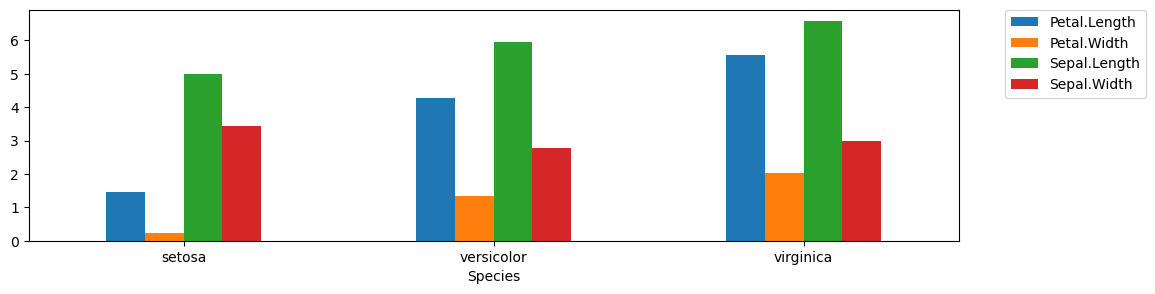

In [72]:
# 범례를 밖으로 : 시각화20page. 판다스60page
import matplotlib.pyplot as plt
g.plot(kind='bar', figsize=(12,3), rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [73]:
iris.pivot_table(index='Species', values='Sepal.Length', aggfunc='count')
iris.groupby('Species')['Sepal.Length'].count()
iris['Species'].value_counts() # 정렬까지

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [74]:
# 임의로 각 열마다 결측치를 할당(0번째 열은 결측치1 / 1번째열은 결측치2 / 2번째열은 결측치3 / 3번째열은 결측치4)
import numpy as np
import random
# random.sample(range(0,150), 3)
for col in range(iris.shape[1]-1): 
    rows = random.sample(range(len(iris)), col+1)
    iris.iloc[rows, col] = np.nan

In [75]:
# 열별 결측치를 제외한 데이터 갯수
iris.groupby('Species').count()
iris.pivot_table(index='Species', aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,49,50,50,50
versicolor,49,48,50,49
virginica,49,48,49,49


### 다중열로 그룹화

In [76]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [77]:
# iris로 다중열 그룹화하기 위해 데이터 추가(num 컬럼)
# iris 행수는 150개 = Species 3그룹, num 6그룹
iris['num'] = np.array([[i]*25 for i in range(6)]).flatten()
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [78]:
# 종별, num별 합계
r = iris.groupby(['Species', 'num']).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         87.0          36.5          6.2
           1           124.6         84.4          35.3          6.1
versicolor 2           150.3         66.9         107.8         32.2
           3           146.5         69.1         101.4         31.5
virginica  4           164.4         73.2         135.9         46.7
           5           158.7         72.1         136.6         50.2

In [79]:
r.loc[['setosa','virginica']] # setosa와 virginica의 합계만 

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         87.0          36.5          6.2
          1           124.6         84.4          35.3          6.1
virginica 4           164.4         73.2         135.9         46.7
          5           158.7         72.1         136.6         50.2

In [80]:
r.loc[[('setosa',0),('virginica',5)]] # num이 0과 5인 합계만

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,87.0,36.5,6.2
virginica,5,158.7,72.1,136.6,50.2


In [81]:
# 종별, num별 합계
iris.pivot_table(index=['Species', 'num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.460000     0.248000        5.0280     3.480000
           1        1.470833     0.244000        4.9840     3.376000
versicolor 2        4.312000     1.341667        6.0120     2.787500
           3        4.225000     1.312500        5.8600     2.764000
virginica  4        5.662500     2.030435        6.5760     2.928000
           5        5.464000     2.008000        6.6125     3.004167

In [82]:
# 종별 기초통계량들
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  50.000000   50.000000  49.000000
             mean    5.006000    5.936000   6.593878
             std     0.352490    0.516171   0.641095
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.200000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  50.000000   49.000000  49.000000
             mean    3.428000    2.775510   2.965306
             std     0.379064    0.314597   0.319864
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.600000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.100000
             max     4.400000    3.400000   3.800000
Petal.Length count  49.000000   49.000000  49.000000
             mean    1.465306    4.269388   5.561224
             std     0.173867    0.470020   0.553706
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.400000   5.600000
             75%     1.600000    4.600000   5.900000
             max     1.900000    5.100000   6.900000
Petal.Width  count  50.000000   48.000000  48.000000
             mean    0.246000    1.327083   2.018750
             std     0.105386    0.200785   0.274952
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000

## 9.2 그룹 간 데이터 처리

In [83]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [84]:
iris_grouped = iris.groupby('Species')
iris_grouped

In [85]:
# 종별 상위 3행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.head(3))

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica


In [86]:

# 종별 임의의 표본 3행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.sample(3).sort_index())#.reset_index(drop=True))


setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
9,4.9,3.1,1.5,0.1,setosa
26,5.0,3.4,1.6,0.4,setosa
31,5.4,3.4,1.5,0.4,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
73,6.1,2.8,4.7,1.2,versicolor
74,6.4,2.9,4.3,1.3,versicolor
77,6.7,3.0,5.0,1.7,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
106,4.9,2.5,4.5,1.7,virginica
115,6.4,3.2,5.3,2.3,virginica
122,7.7,2.8,6.7,2.0,virginica


In [87]:
# 종별 0,15,30,45번째행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.iloc[[0,15,30,45]])

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
30,4.8,3.1,1.6,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
65,6.7,3.1,4.4,1.4,versicolor
80,5.5,2.4,3.8,1.1,versicolor
95,5.7,3.0,4.2,1.2,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
115,6.4,3.2,5.3,2.3,virginica
130,7.4,2.8,6.1,1.9,virginica
145,6.7,3.0,5.2,2.3,virginica


## 9.3 데이터프레임 그룹별 인덱싱

In [88]:
# 종별 0,15,30,45번째행 출력
# for speciesname, group in iris_grouped:
#     print(speciesname)
#     display(group.iloc[[0,15,30,45]])
r = iris.groupby('Species').take([0,15,30,40])
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species                                                             
setosa     0             5.1          3.5           1.4          0.2
           15            5.7          4.4           1.5          0.4
           30            4.8          3.1           1.6          0.2
           40            5.0          3.5           1.3          0.3
versicolor 50            7.0          3.2           4.7          1.4
           65            6.7          3.1           4.4          1.4
           80            5.5          2.4           3.8          1.1
           90            5.5          2.6           4.4          1.2
virginica  100           6.3          3.3           6.0          2.5
           115           6.4          3.2           5.3          2.3
           130           7.4          2.8           6.1          1.9
           140           6.7          3.1           5.6          2.4

In [89]:
r.loc['versicolor']

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
50,7.0,3.2,4.7,1.4
65,6.7,3.1,4.4,1.4
80,5.5,2.4,3.8,1.1
90,5.5,2.6,4.4,1.2


# 10절. 데이터 구조 변경
- 와이드포맷 <---> 롱포맷(tidy data)
- 판다스 공식문서에 나오는 melt : https://pandas.pydata.org/docs/user_guide/reshaping.html#melt-and-wide-to-long
- Tidy Data : https://vita.had.co.nz/papers/tidy-data.pdf

In [90]:
from statsmodels.api import datasets
airquality = datasets.get_rdataset('airquality').data # 1973년 뉴욕 공기 질 데이터셋
airquality

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29


## 10.1 melt를 이용한 언피벗팅(와이드포맷 → 롱포맷)
- df.melt(id_vars, value_vars, var_name, value_name)
- pd.melt(df, id_vars, value_vars, var_name, value_name)

In [91]:
# pd.melt(airquality, id_vars=['Month','Day'])
airquality_melted = airquality.melt(id_vars=['Month','Day'],
                                   # value_vars=['Ozone', 'Solar.R', 'Wind', 'Temp'] melt될 열이름
                                   )
airquality_melted

,Month,Day,variable,value
0,5,1,Ozone,41.0
1,5,2,Ozone,36.0
2,5,3,Ozone,12.0
3,5,4,Ozone,18.0
4,5,5,Ozone,NaN
...,...,...,...,...
607,9,26,Temp,70.0
608,9,27,Temp,77.0
609,9,28,Temp,75.0
610,9,29,Temp,76.0


In [92]:
airquality_melted = airquality.melt(id_vars=['Month','Day'],
                                   var_name='변수명', # melt된 데이터의 열이름
                                   value_name='값')   # 데이터가 된 열이름
airquality_melted = airquality_melted.sort_values(by=['Month', 'Day']).reset_index(drop=True)
airquality_melted

,Month,Day,변수명,값
0,5,1,Ozone,41.0
1,5,1,Solar.R,190.0
2,5,1,Wind,7.4
3,5,1,Temp,67.0
4,5,2,Ozone,36.0
...,...,...,...,...
607,9,29,Temp,76.0
608,9,30,Ozone,20.0
609,9,30,Solar.R,223.0
610,9,30,Wind,11.5


## 10.2 pivot_table을 이용한 피벗팅(롱포맷 → 와이드포맷)
- df.pivot_table(index, columns, values)
- pd.pivot_table(df, index, columns, values)

In [93]:
# pd.pivot_table(airquality_melted, index=['Month','Day'], columns='변수명', values='값')
airqulity2 = airquality_melted.pivot_table(index=['Month','Day'],
                             columns='변수명',
                            # values="값"
                             )
airqulity2.columns = airqulity2.columns.droplevel(level=0)
airqulity2.columns.name = None
airqulity2 = airqulity2.reset_index()
airqulity2

# 11절. 데이터프레임에 함수 적용시키기
- apply(func, axis) : 데이터프레임이나 시리즈 모두 적용가능
- map(func) : 각 요소별로 func 적용(1차원 시리즈에서만 가능)
- applymap(func) : 각 요소별로 func 적용(데이터프레임에서만 가능)
## 11.1 apply/map

In [94]:
# ex1. 1차원 시리즈에 apply/map 이용
import pandas as pd
member = pd.read_csv('data/ch11_member.csv', comment='#')
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     5 non-null      object
 1   Age      5 non-null      int64 
 2   Email    5 non-null      object
 3   Address  5 non-null      object
 4   Birth    5 non-null      object
dtypes: int64(1), object(4)
memory usage: 328.0+ bytes


In [95]:
def get_year(datestr):
    return int(datestr.split('-')[0])
get_year = lambda datestr : int(datestr.split('-')[0])
get_year("1999-01-01")

1999

In [96]:
def get_month(x):
    return int(x.split('-')[1])
get_month = lambda x : int(x.split('-')[1])
get_month("1999-01-01")

0    1999-01-01
1    1999-12-01
2    1999-11-01
3    1999-05-01
4    1999-01-30
Name: Birth, dtype: object

In [98]:
member['년'] = member['Birth'].map(lambda datestr : int(datestr.split('-')[0]))
member['월'] = member['Birth'].apply(lambda x : int(x.split('-')[1]))
member

,Name,Age,Email,Address,Birth,년,월
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1


In [99]:
# ex2. 2차원 데이터프레임에서 apply(func, axis)
%ls "c:/ai/downloads/shareData/분양가격"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: A014-DCD6

 c:\ai\downloads\shareData\분양가격 디렉터리

2026-07-14  오후 05:34    <DIR>          .
2026-07-14  오후 05:48    <DIR>          ..
2026-06-24  오후 10:04             2,163 전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv
2026-07-13  오후 10:37           501,367 주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv
               2개 파일             503,530 바이트
               2개 디렉터리  158,034,354,176 바이트 남음


In [100]:
df_last = pd.read_csv('c:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv',
                     encoding='cp949')
df_last.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652


In [101]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [103]:
def year_month(series):
    return "{}-{:02}".format(series['연도'], series['월'])
    #return str(series['연도']) + "-" + \
    #        (str(series['월']) if series['월']>=10 else ("0"+str(series['월'])))
year_month(df_last.loc[300])

'2016-01'

In [104]:
df_last['연도월'] = \
        df_last.apply(lambda series : "{}-{:02}".format(series['연도'], series['월']), axis=1)
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
10875,제주,모든면적,2026,5,4473,2026-05
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,2026-05
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485,2026-05
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,2026-05
10879,제주,전용면적 102제곱미터초과,2026,5,4350,2026-05


In [105]:
# ex3. iris 에서 apply
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [106]:
import numpy as np
X = iris.iloc[:,:-1]
avg = np.mean(X, axis=0)
avg = X.mean(axis=0) # 열별평균
avg

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [107]:
# 각 열별 평균과의 거리를 출력
X.apply(lambda x: round(x-avg, 2), axis=1)

,sepal_length,sepal_width,petal_length,petal_width
0,-0.74,0.44,-2.36,-1.0
1,-0.94,-0.06,-2.36,-1.0
2,-1.14,0.14,-2.46,-1.0
3,-1.24,0.04,-2.26,-1.0
4,-0.84,0.54,-2.36,-1.0
...,...,...,...,...
145,0.86,-0.06,1.44,1.1
146,0.46,-0.56,1.24,0.7
147,0.66,-0.06,1.44,0.8
148,0.36,0.34,1.64,1.1


## 11.2 applymap

In [109]:
X.applymap(lambda x : round(x, 3))

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


※ melt() 및 함수 적용시키기 연습예제 (분양가격 csv 두파일 통합)

- 와이드포맷 → 롱포맷(melt) : 2013~2015년데이터
- 평당분양가격/3.3 => 분양가격(제곱미터당 천원)
- 2013년12월 -> 2013과 12을 나눠 '연도'와 '월' 컬럼(apply, map) => new_first
- df_last['규모구분']=='모든면적' 데이터만 추출(지역명, 연도, 월, 분양가격(제곱미터당 천원)컬럼만)
- df_last의 지역명 컬럼명을 지역으로 변경 => new_last
- pd.concat([new_first, new_last])

In [110]:
df_last.head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
0,서울,모든면적,2015,10,5841,2015-10


In [111]:
df_first = pd.read_csv('c:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [112]:
# 와이드포맷 -> 롱포맷
new_first = df_first.melt(id_vars='지역', var_name='연도월', value_name='평당분양가격')
new_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      357 non-null    object
 1   연도월     357 non-null    object
 2   평당분양가격  357 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 8.5+ KB


In [113]:
# 평당분양가격/3.3 => 제곱미터당분양가격
new_first['분양가격(제곱미터당 천원)'] = new_first['평당분양가격'] / 3.3
new_first.head()

,지역,연도월,평당분양가격,분양가격(제곱미터당 천원)
0,서울,2013년12월,18189,5511.818182
1,부산,2013년12월,8111,2457.878788
2,대구,2013년12월,8080,2448.484848
3,인천,2013년12월,10204,3092.121212
4,광주,2013년12월,6098,1847.878788


In [117]:
# 2013년12월 -> 2013과 12을 나눠 '연도'와 '월' 컬럼(apply, map)
def parse_year(datestr):
    return int(datestr.split('년')[0])
(lambda datestr : int(datestr.split('년')[0]))("2013년12월")
def parse_month(datestr):
    return int(datestr.split('년')[1][:-1])
parse_month("2013년12월")

12

In [118]:
new_first['연도'] = new_first['연도월'].map(lambda datestr : int(datestr.split('년')[0]))
new_first['월']  = new_first['연도월'].apply(lambda datestr : int(datestr.split('년')[1][:-1]))
new_first.drop(['연도월','평당분양가격'], axis=1, inplace=True) # 불필요한 컬럼 drop
new_first.head(1)

,지역,분양가격(제곱미터당 천원),연도,월
0,서울,5511.818182,2013,12


In [121]:
# df_last['규모구분']=='모든면적' 데이터만 추출(지역명, 연도, 월, 분양가격(제곱미터당 천원)컬럼만)
new_last = df_last.loc[df_last['규모구분']=='모든면적', ['지역명','연도','월','분양가격(제곱미터당 천원)']]
# 지역명 컬럼명을 지역으로 변경 => new_last
# new_last.columns = ['지역','연도','월','분양가격(제곱미터당 천원)']
new_last.rename(columns={'지역명':'지역'}, inplace=True) # 지역명 컬럼명을 지역으로 변경
new_last.head(1)

,지역,연도,월,분양가격(제곱미터당 천원)
0,서울,2015,10,5841


In [122]:
# concat
df = pd.concat([new_first, new_last],
              #axis=0
              ).reset_index(drop=True) # 같은 컬럼명 기준으로 행 연결
df.loc[[0,10,20]]

,지역,분양가격(제곱미터당 천원),연도,월
0,서울,5511.818182,2013,12
10,충북,1996.666667,2013,12
20,인천,3092.121212,2014,1


# 12절. 일괄변경하기(결측치나 특정값)

## 12.1 fillna(결측치를 어떤 값으로 대체)

- 대부분의 결측치는 drop하거나, 평균값대체, 중위수(중앙값, 2사분위수)대체, 최빈값대체, 이전값, 다음값, 그룹별평균값으로 대체

In [124]:
df = pd.DataFrame([[np.nan, 2, np.nan, 0],
                   [3,      4, np.nan, 1],
                   [np.nan, 3, np.nan, 5],
                   [np.nan, 3, np.nan, 4]], columns=list('ABCD'))
df

,A,B,C,D
0,NaN,2,NaN,0
1,3.0,4,NaN,1
2,NaN,3,NaN,5
3,NaN,3,NaN,4


In [125]:
# 모든 결측치를 무조건 0으로 대체
df.fillna(0)

,A,B,C,D
0,0.0,2,0.0,0
1,3.0,4,0.0,1
2,0.0,3,0.0,5
3,0.0,3,0.0,4


In [126]:
# 결측치를 이전행의 값으로 대체
df.fillna(method='ffill')

,A,B,C,D
0,NaN,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [127]:
# 결측치를 다음행의 값으로 대체
df.fillna(method='bfill')

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,NaN,3,NaN,5
3,NaN,3,NaN,4


In [128]:
# 결측치를 열마다 특정값으로 대체
values = {'A':99, 'B':98, 'C':97, 'D':96}
df.fillna(value=values)

,A,B,C,D
0,99.0,2,97.0,0
1,3.0,4,97.0,1
2,99.0,3,97.0,5
3,99.0,3,97.0,4


In [129]:
# 결측치를 각 열의 평균값으로 대체
df.mean(axis=0)
df.fillna(value=df.mean(axis=0))

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [130]:

# 결측치를 각 열의 평균값으로 대체(결측치 대체는 2번째까지만)
df.fillna(value=df.mean(axis=0), limit=2)

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,NaN,3,NaN,4


In [131]:
# 결측치를 각 열의 중위수(중앙값)으로 대체
df.fillna(value=df.median(axis=0))

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [132]:
# 결측치를 각 열의 최빈값으로 대체
df.fillna(df.mode().loc[0])

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


## 12.2 replace(to_value, new_value, inplace=T/F)
- to_value를 new_value로 변경
- to_value에는 정규표현식 이용 가능

In [133]:
s = pd.Series([0, 1, 2, 3, None])
s.replace(np.nan, 0, inplace=True)
s.replace([0,1], 99) # 0이나 1을 99로 변경

0    99.0
1    99.0
2     2.0
3     3.0
4    99.0
dtype: float64

In [134]:
s = pd.Series([0, 1, 2, 3, None])
s.replace([0,1,2],[100,101,102])

0    100.0
1    101.0
2    102.0
3      3.0
4      NaN
dtype: float64

In [135]:
df = pd.DataFrame({'A': ['bat', 'foo', 'bait'],
                   'B': ['abc', 'bar', 'xyz']})
df

,A,B
0,bat,abc
1,foo,bar
2,bait,xyz


In [136]:
df.replace('ba.+', 'XX', regex=True)
df.replace('^ba.+$', 'XX', regex=True)
df.replace(regex='ba.+', value='XX')
df.replace(regex=['ba.+','fo.'], value='XX')

,A,B
0,XX,abc
1,XX,XX
2,XX,xyz


In [137]:
df.replace({'A':'bat', 'B':'abc'}, 'XX')

,A,B
0,XX,XX
1,foo,bar
2,bait,xyz


## 12.3 where(조건), mask(조건)

In [138]:
# 넘파이 where
a = np.array([1,2,3,4,5,6])
np.where(a>3)

(array([3, 4, 5], dtype=int64),)

In [139]:
s = pd.Series(range(10,20))
s

0    10
1    11
2    12
3    13
4    14
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [140]:
# 15이상
s[s>=15]

5    15
6    16
7    17
8    18
9    19
dtype: int64

In [141]:
s.where(s>=15) # 조건이 만족되는 데이터는 그대로 출력. 만족되지 않는 데이터는 결측치

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5    15.0
6    16.0
7    17.0
8    18.0
9    19.0
dtype: float64

In [142]:
s.where(s>=15, other=-1) # 조건이 만족되는 데이터는 그대로 출력. 만족되지 않는 데이터는 -1

0    -1
1    -1
2    -1
3    -1
4    -1
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [143]:
s.mask(s>=15) # 조건이 만족되는 데이터만 결측치

0    10.0
1    11.0
2    12.0
3    13.0
4    14.0
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
dtype: float64

## 12.4 dropna
- 결측치가 있는 데이터 누락(행기준, 열기준)

In [144]:
df = pd.DataFrame({'name':['홍','김', np.nan, np.nan],
                   'age' : [np.nan, 20, 30, np.nan],
                   'born':['서울','부산',np.nan, np.nan]})
df

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,NaN


In [145]:
df.dropna(#axis=0
         ) # 결측치가 하나라도 있는 행을 drop. inplace=True가 아니면 return

,name,age,born
1,김,20.0,부산


In [146]:
df.dropna(thresh=2) # 결측치가 아닌값이 2개 이상이면 drop 안 함

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산


In [147]:
df.dropna(subset=['name', 'age']) #name열과 age열에 결측치가 하나라도 있는 행 drop

,name,age,born
1,김,20.0,부산


In [148]:
df.dropna(how='all') # 모두 결측치인 행 drop

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN


In [149]:
df.dropna(axis=1) # 결측치가 하나라도 있는 열은 drop

""
0
1
2
3


In [150]:
df.dropna(axis=1, how='all') # 모두 결측치인 열은 drop

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,NaN


### ※ iris 결측치를 열별 평균으로 대체(교안 80p : fillna)

In [151]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [152]:
iris.isna().sum() # 열마다 결측치 갯수
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [153]:
iris.notna().sum() # 열마다 결측치를 제외한 데이터 갯수
iris.notnull().sum()

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [157]:
# 1단계 : iris 데이터에서 결측치를 인위적으로 random하게 열 마다 20씩 결측치를 할당한다
import random
print(random.sample(range(iris.shape[0]),20))

[98, 118, 106, 90, 128, 19, 65, 76, 22, 111, 149, 117, 123, 5, 88, 96, 54, 13, 16, 102]


In [158]:
for col in range(iris.shape[1]-1):
    randomidx = random.sample(range(iris.shape[0]), 20)
    # print(randomidx, col)
    iris.iloc[randomidx, col] = np.nan
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [159]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,NaN,3.0,1.4,0.2,setosa
2,NaN,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,NaN,setosa


In [160]:
# 2단계 : 결측치가 있는 iris데이터를 출력한다
iris[iris['sepal_length'].isna() | iris['sepal_width'].isna() | 
     iris['petal_length'].isnull() | iris['petal_width'].isnull()]

,sepal_length,sepal_width,petal_length,petal_width,species
1,NaN,3.0,1.4,0.2,setosa
2,NaN,3.2,1.3,0.2,setosa
4,5.0,3.6,1.4,NaN,setosa
5,5.4,3.9,NaN,0.4,setosa
8,NaN,2.9,1.4,0.2,setosa
...,...,...,...,...,...
141,6.9,3.1,NaN,NaN,virginica
145,6.7,3.0,NaN,2.3,virginica
146,6.3,NaN,NaN,1.9,virginica
147,6.5,3.0,5.2,NaN,virginica


In [161]:
# 3단계 : 결측치를 열평균으로 대체된 iris데이터를 출력
iris.iloc[:,:-1].mean(axis=0) # 열평균
iris.mean(axis=0, numeric_only=True) # 열평균
iris_fillna = iris.fillna(value=iris.iloc[:,:-1].mean(axis=0))
iris_fillna.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [162]:
# 소수점 3자리에서 반올림
iris_fillna.iloc[:, :-1] = iris_fillna.iloc[:, :-1].applymap(lambda x : np.round(x, 3))
iris_fillna

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.10,3.500,1.400,0.200,setosa
1,5.87,3.000,1.400,0.200,setosa
2,5.87,3.200,1.300,0.200,setosa
3,4.60,3.100,1.500,0.200,setosa
4,5.00,3.600,1.400,1.155,setosa
...,...,...,...,...,...
145,6.70,3.000,3.634,2.300,virginica
146,6.30,3.055,3.634,1.900,virginica
147,6.50,3.000,5.200,1.155,virginica
148,6.20,3.400,5.400,2.300,virginica


### ※ iris 결측치를 종별, 열별 평균으로 대체(apply적용)

In [163]:
# 결측치를 종별, 열평균으로 대체된 iris데이터를 출력
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [164]:
iris_mean = iris.groupby(by=['species']).mean()
iris_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.025000,3.386364,1.461702,0.247826
versicolor,5.909091,2.793182,4.241860,1.339130
virginica,6.567391,2.983333,5.532500,2.028947


In [165]:
iris.fillna(value=iris_mean) # 결측치 대체값이 iris_mean이면 대체가 안 됨

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,NaN,3.0,1.4,0.2,setosa
2,NaN,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,NaN,setosa
...,...,...,...,...,...
145,6.7,3.0,NaN,2.3,virginica
146,6.3,NaN,NaN,1.9,virginica
147,6.5,3.0,5.2,NaN,virginica
148,6.2,3.4,5.4,2.3,virginica


In [166]:
iris_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.025000,3.386364,1.461702,0.247826
versicolor,5.909091,2.793182,4.241860,1.339130
virginica,6.567391,2.983333,5.532500,2.028947


In [167]:
iris_mean.loc['setosa', 'sepal_length']

5.025

In [178]:
# np.isnan(스칼라값) : nan만 결측치로 인식, 결측치인지 여부(값이 숫자형이어야 함)
# pd.isna(스칼라값), pd.isnull(스칼라값) : nan과 None을 모두 결측치로 인식, 결측치인지 여부(값이 숫자형이 아니어도 됨)
def fillna_grouped_mean(row):
    row = row.copy()
    for col, item in row.items():
        # print(col, item, row[col])
        # item이 결측치이면 해당 species가져와서 대체할 결측치를 iris_mean.loc[종이름, col]로 대체
        #if col!='species' and np.isnan(item): # 결측치인지 여부
        if pd.isna(item):
            species = row['species']
            row[col] = iris_mean.loc[species, col] # 종별 열별 평균값으로 대체
    return row

fillna_grouped_mean(iris.iloc[2])

Sepal.Length       4.7
Sepal.Width        3.2
Petal.Length       1.3
Petal.Width        0.2
Species         setosa
Name: 2, dtype: object

In [179]:

iris.apply(fillna_grouped_mean, axis=1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# 13절. 시리즈
- 1차원 데이터

In [180]:
s = pd.Series([1000,7000,5000], index=['banana','mango','apple'])
s

banana    1000
mango     7000
apple     5000
dtype: int64

In [181]:
s['banana'], s.banana

(1000, 1000)

In [182]:
s['banana':'apple']

banana    1000
mango     7000
apple     5000
dtype: int64

In [183]:
s['watermelon'] = 20000 # 데이터 추가
s

banana         1000
mango          7000
apple          5000
watermelon    20000
dtype: int64

In [184]:
s.drop('watermelon', inplace=True) # 데이터 drop
s

banana    1000
mango     7000
apple     5000
dtype: int64

In [185]:
s = s.sort_index()
s

apple     5000
banana    1000
mango     7000
dtype: int64

In [186]:
s.sort_values() # 값에 의한 정렬(기본은 ascending=True 오름차순)

banana    1000
apple     5000
mango     7000
dtype: int64

In [187]:
s.sort_values(ascending=False) # 내림차순

mango     7000
apple     5000
banana    1000
dtype: int64

In [188]:
s.to_frame(name='price') # 열이름을 지정하여 데이터프레임으로 전환

,price
apple,5000
banana,1000
mango,7000


In [189]:
s.to_frame(name='price').T

,apple,banana,mango
price,5000,1000,7000


# 14절. 연습문제

In [190]:
import seaborn as sns
iris = sns.load_dataset("iris")
type(iris)

pandas.core.frame.DataFrame

In [192]:
# 1. iris 데이터에서 처음 다섯개 행만 출력하세요
print(iris.head(5))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
# 2. iris 데이터를 데이터프레임 변수인 독립변수 X와 종속변수 y로 나누세요. 종속변수는 species 열입니다.

In [ ]:
3. iris 데이터에서 처음 50개행을 빼내서 temp변수에 저장하세요

In [ ]:
4. 3번에서 선택한 데이터프레임의 요약정보를 출력하세요. 모든 열에 대해 요약정보가
출력되어야 합니다.

In [ ]:
5. versicolor종의 데이터만 iris_versicolor변수에 저장하세요

In [ ]:
6. 2번의 X와 y변수를 합해서 iris_df데이터 프레임으로 만드세요